# House Price Prediction
**Objective:** Predict house prices using property features such as size, number of bedrooms, and location.

In [15]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [16]:
# Load dataset
df = pd.read_csv('House Price Prediction Dataset.csv')

# Display basic info
print(df.head())
print(df.columns)
print(df.info())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 no

In [17]:
# Remove unnecessary column
df = df.drop('Id', axis=1)

# Handle missing values (if any)
df = df.dropna()

# Separate target and features
X = df.drop('Price', axis=1)
y = df['Price']

# Convert categorical data into numerical
X = pd.get_dummies(X, drop_first=True)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [21]:
gb = GradientBoostingRegressor(n_estimators=300, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [22]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"{name} Results:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print("-"*30)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_gb, "Gradient Boosting")

Linear Regression Results:
MAE: 243241.98
RMSE: 279859.73
------------------------------
Gradient Boosting Results:
MAE: 253897.77
RMSE: 297175.27
------------------------------


In [24]:
importances = gb.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

              Feature  Importance
0                Area    0.520110
4           YearBuilt    0.176825
1            Bedrooms    0.066352
2           Bathrooms    0.060337
3              Floors    0.046322
7      Location_Urban    0.031655
10     Condition_Poor    0.023239
6   Location_Suburban    0.020184
8      Condition_Fair    0.018384
9      Condition_Good    0.016390


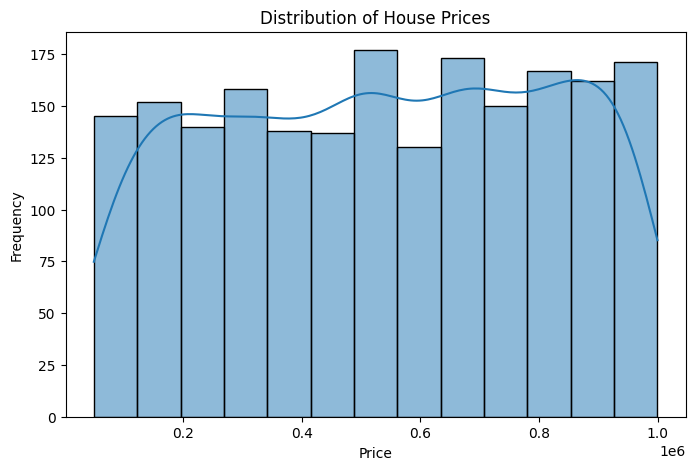

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

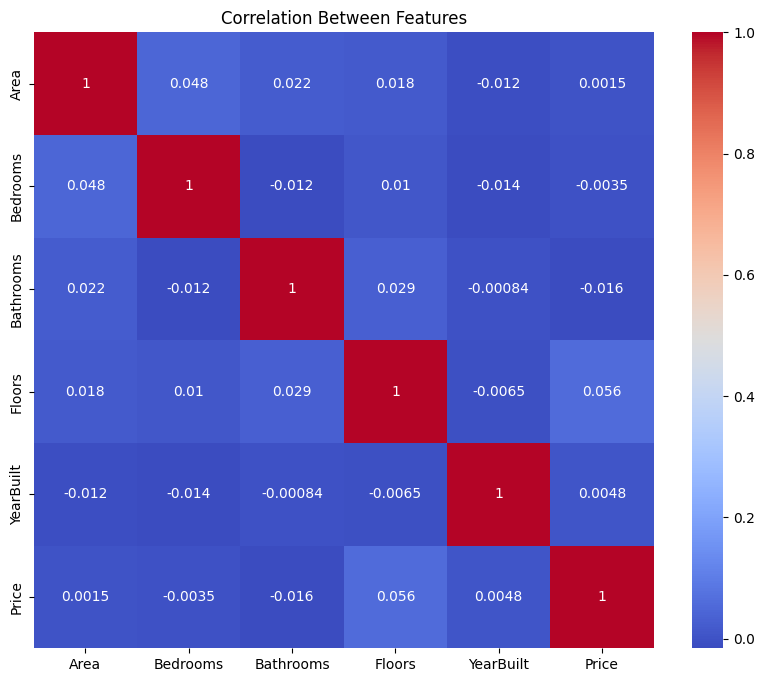

In [29]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Between Features")

plt.show()

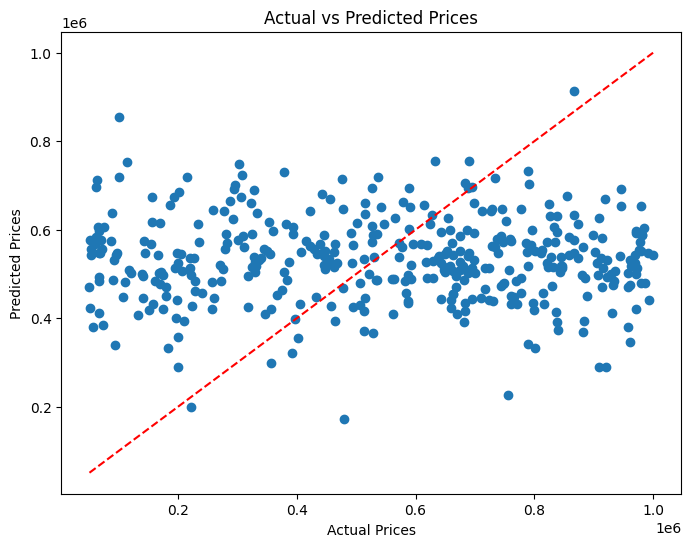

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_gb)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

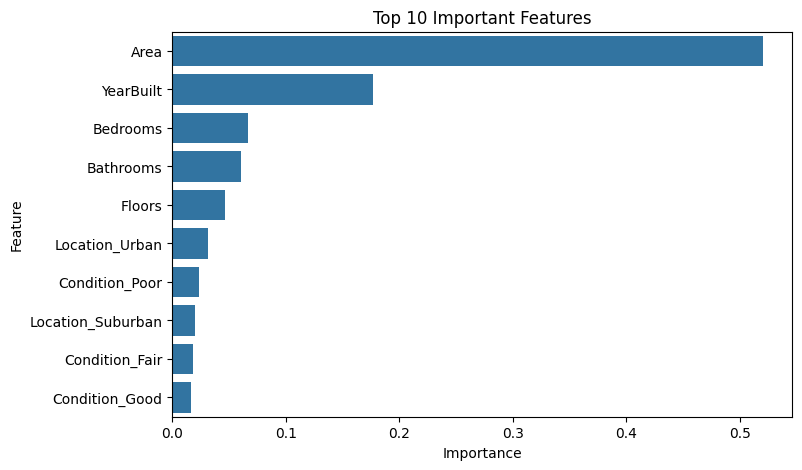

In [31]:
importance_df = importance_df.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance_df)

plt.title("Top 10 Important Features")

plt.show()

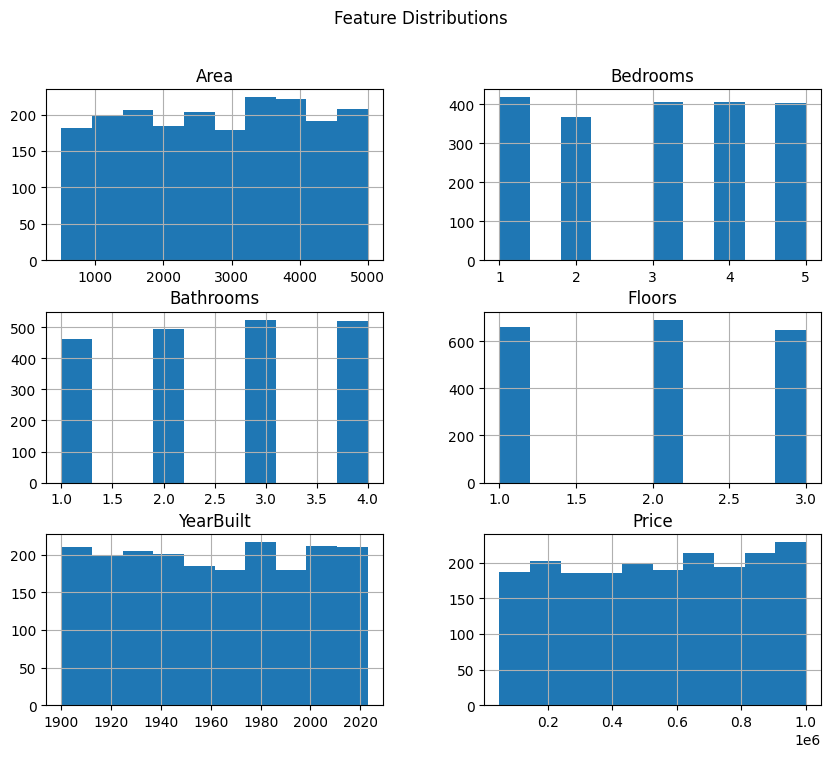

In [32]:
# Histogram
df.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()